In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)  # show all columns instead of truncating

In [46]:
df = pd.read_excel("data/online_retail.xlsx")
print("Rows and columns:", df.shape)
df.head()

Rows and columns: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [47]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


In [48]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [49]:
print("Missing CustomerID:", df["CustomerID"].isna().sum())
print("Quantity <= 0:     ", (df["Quantity"] <= 0).sum())
print("UnitPrice <= 0:    ", (df["UnitPrice"] <= 0).sum())

cancellations = df["InvoiceNo"].astype(str).str.startswith("C")
print("Cancellations (InvoiceNo starts with 'C'):", cancellations.sum())

Missing CustomerID: 135080
Quantity <= 0:      10624
UnitPrice <= 0:     2517
Cancellations (InvoiceNo starts with 'C'): 9288


In [50]:
df[cancellations].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom


In [51]:
# Forecasting dataset: we only need date + money, the customer is irrelevant here
sales = df.copy()
sales["Revenue"] = sales["Quantity"] * sales["UnitPrice"]

# Keep only real purchases: drop returns (negative quantity) and invalid prices
sales = sales[(sales["Quantity"] > 0) & (sales["UnitPrice"] > 0)]

print("Before cleaning:", df.shape[0], "rows")
print("After cleaning: ", sales.shape[0], "rows")
print(
    "Revenue range: ",
    round(sales["Revenue"].min(), 2),
    "...",
    round(sales["Revenue"].max(), 2),
)

Before cleaning: 541909 rows
After cleaning:  530104 rows
Revenue range:  0.0 ... 168469.6


In [52]:
# Daily revenue time series
daily = sales.groupby(sales["InvoiceDate"].dt.date)["Revenue"].sum().reset_index()
daily.columns = ["date", "revenue"]
daily["date"] = pd.to_datetime(daily["date"])

print("Number of days:", daily.shape[0])
daily.head()

Number of days: 305


,date,revenue
0,2010-12-01,58960.79
1,2010-12-02,47748.38
2,2010-12-03,46943.71
3,2010-12-05,31774.95
4,2010-12-06,54830.46


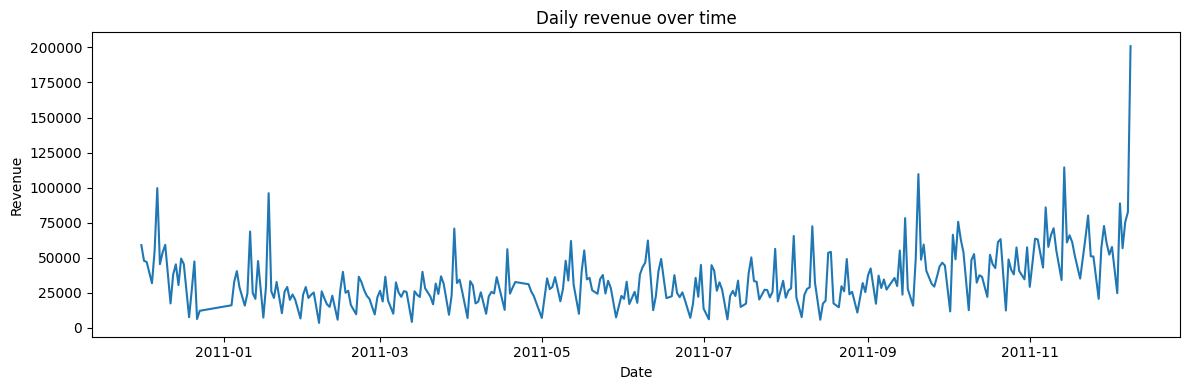

In [53]:
plt.figure(figsize=(12, 4))
plt.plot(daily["date"], daily["revenue"])
plt.title("Daily revenue over time")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

In [54]:
# Turn the time series into a supervised learning problem.
# Each day gets the revenue of the previous 7 (trading) days as features.
data = daily.copy()
for lag in range(1, 8):
    data[f"lag{lag}"] = data["revenue"].shift(lag)

# The first 7 rows have no full history, so we drop them.
data = data.dropna().reset_index(drop=True)

print("Shape with lags:", data.shape)
data.head()

Shape with lags: (298, 9)


,date,revenue,lag1,lag2,lag3,lag4,lag5,lag6,lag7
0,2010-12-09,53586.18,45389.98,99618.20,54830.46,31774.95,46943.71,47748.38,58960.79
1,2010-12-10,59182.92,53586.18,45389.98,99618.20,54830.46,31774.95,46943.71,47748.38
2,2010-12-12,17329.07,59182.92,53586.18,45389.98,99618.20,54830.46,31774.95,46943.71
3,2010-12-13,38006.71,17329.07,59182.92,53586.18,45389.98,99618.20,54830.46,31774.95
4,2010-12-14,45254.73,38006.71,17329.07,59182.92,53586.18,45389.98,99618.20,54830.46


In [55]:
from sklearn.model_selection import train_test_split

X = data.drop(columns=["date", "revenue"])
y = data["revenue"]

# shuffle=False keeps chronological order: train on the past, test on the future
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

n_train = X_train.shape[0]
print("Train size:", n_train)
print("Test size: ", X_test.shape[0])
print(
    "Train period:",
    data["date"].iloc[0].date(),
    "->",
    data["date"].iloc[n_train - 1].date(),
)
print(
    "Test period: ",
    data["date"].iloc[n_train].date(),
    "->",
    data["date"].iloc[-1].date(),
)

Train size: 238
Test size:  60
Train period: 2010-12-09 -> 2011-09-30
Test period:  2011-10-02 -> 2011-12-09


In [56]:
from sklearn.metrics import root_mean_squared_error

# Naive baseline: predict each day's revenue as the previous day's (persistence).
# lag1 is exactly the previous trading day's revenue, so this is the simplest possible forecast.
baseline_pred = X_test["lag1"].values
baseline_rmse = root_mean_squared_error(y_test, baseline_pred)
print("Naive baseline RMSE:", round(baseline_rmse, 2))

Naive baseline RMSE: 30373.44


In [57]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error

rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_rmse = root_mean_squared_error(y_test, rf_pred)
print("Random Forest RMSE:", round(rf_rmse, 2))

Random Forest RMSE: 26866.36


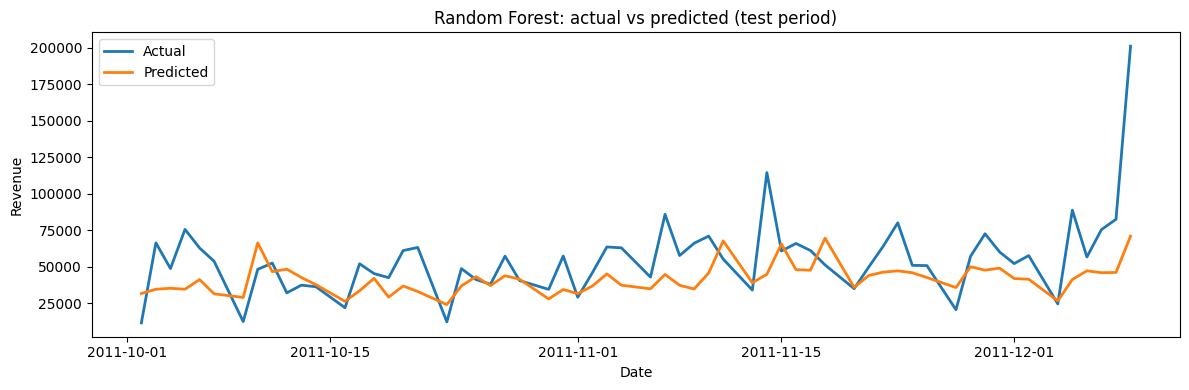

In [58]:
test_dates = data["date"].iloc[n_train:]

plt.figure(figsize=(12, 4))
plt.plot(test_dates, y_test.values, label="Actual", linewidth=2)
plt.plot(test_dates, rf_pred, label="Predicted", linewidth=2)
plt.title("Random Forest: actual vs predicted (test period)")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.legend()
plt.tight_layout()
plt.show()

In [59]:
from xgboost import XGBRegressor

xgb = XGBRegressor(n_estimators=300, learning_rate=0.05, random_state=42)
xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

xgb_rmse = root_mean_squared_error(y_test, xgb_pred)
print("XGBoost RMSE:", round(xgb_rmse, 2))

XGBoost RMSE: 27763.78


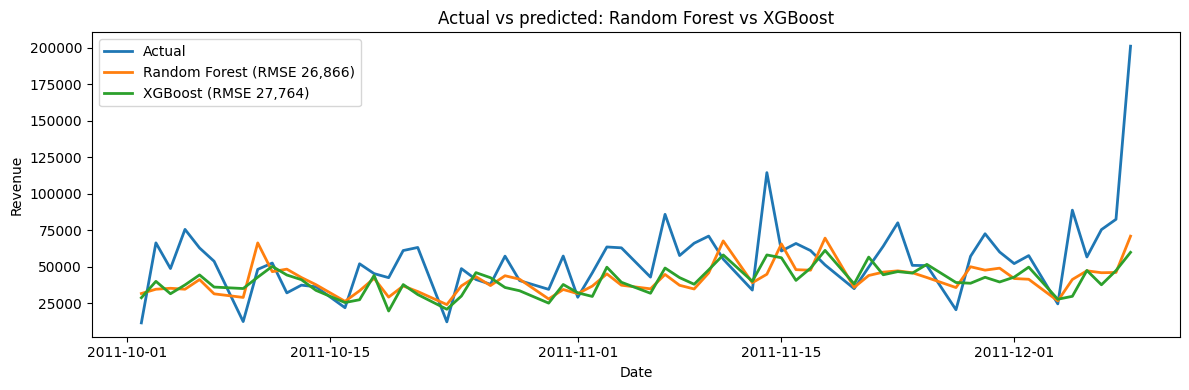

In [60]:
plt.figure(figsize=(12, 4))
plt.plot(test_dates, y_test.values, label="Actual", linewidth=2)
plt.plot(test_dates, rf_pred, label=f"Random Forest (RMSE {rf_rmse:,.0f})", linewidth=2)
plt.plot(test_dates, xgb_pred, label=f"XGBoost (RMSE {xgb_rmse:,.0f})", linewidth=2)
plt.title("Actual vs predicted: Random Forest vs XGBoost")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.legend()
plt.tight_layout()
plt.show()

In [61]:
from sklearn.preprocessing import MinMaxScaler

# Scale to ~0–1. Fit on training data only, then apply to both (no leakage).
feature_scaler = MinMaxScaler()
X_train_scaled = feature_scaler.fit_transform(X_train)
X_test_scaled = feature_scaler.transform(X_test)

target_scaler = MinMaxScaler()
y_train_scaled = target_scaler.fit_transform(y_train.values.reshape(-1, 1))
y_test_scaled = target_scaler.transform(y_test.values.reshape(-1, 1))

# LSTM needs 3D input: (samples, timesteps, features).
# We treat the 7 lags as a 7-step sequence with 1 feature per step.
X_train_lstm = X_train_scaled.reshape(
    (X_train_scaled.shape[0], X_train_scaled.shape[1], 1)
)
X_test_lstm = X_test_scaled.reshape((X_test_scaled.shape[0], X_test_scaled.shape[1], 1))

print("LSTM input shape:", X_train_lstm.shape)

LSTM input shape: (238, 7, 1)


In [62]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input

tf.keras.utils.set_random_seed(42)  # make the result reproducible

model = Sequential(
    [
        Input(shape=(X_train_lstm.shape[1], 1)),
        LSTM(64),
        Dense(1),
    ]
)
model.compile(optimizer="adam", loss="mse")

history = model.fit(
    X_train_lstm,
    y_train_scaled,
    epochs=20,
    batch_size=32,
    verbose=1,
)

Epoch 1/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0522
Epoch 2/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0207 
Epoch 3/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0214 
Epoch 4/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0192 
Epoch 5/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0195 
Epoch 6/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0189 
Epoch 7/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0188 
Epoch 8/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0188 
Epoch 9/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0188 
Epoch 10/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0188 
Epoch 11/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0187 
Epoch 12/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0187 
Epoch 13/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0187 
Epoch 14/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0187 
Epoch 15/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0187 
Epoch 16/20
8/8 ━━━━━━━━━━━━━━━━━━━

In [63]:
lstm_pred_scaled = model.predict(X_test_lstm)
lstm_pred = target_scaler.inverse_transform(lstm_pred_scaled).flatten()

lstm_rmse = root_mean_squared_error(y_test, lstm_pred)
print("LSTM RMSE:", round(lstm_rmse, 2))

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
LSTM RMSE: 30085.89


         Model         RMSE
 Random Forest 26866.363280
       XGBoost 27763.775292
          LSTM 30085.893691
Naive baseline 30373.437378


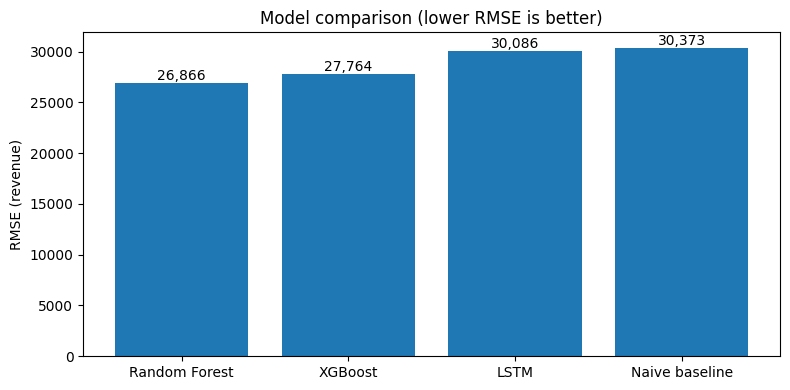

In [64]:
results = (
    pd.DataFrame(
        {
            "Model": ["Naive baseline", "Random Forest", "XGBoost", "LSTM"],
            "RMSE": [baseline_rmse, rf_rmse, xgb_rmse, lstm_rmse],
        }
    )
    .sort_values("RMSE")
    .reset_index(drop=True)
)

print(results.to_string(index=False))

plt.figure(figsize=(8, 4))
bars = plt.bar(results["Model"], results["RMSE"])
plt.title("Model comparison (lower RMSE is better)")
plt.ylabel("RMSE (revenue)")
for bar, value in zip(bars, results["RMSE"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value:,.0f}",
        ha="center",
        va="bottom",
    )
plt.tight_layout()
plt.show()

In [65]:
# Customer analysis & recommendations: the customer is essential here,
# so rows without CustomerID are useless. Returns are not purchases either.
cust = df.copy()
cust = cust[cust["CustomerID"].notna()]  # must have a customer
cust = cust[cust["Quantity"] > 0]  # real purchases only
cust = cust[cust["UnitPrice"] > 0]
cust["Revenue"] = cust["Quantity"] * cust["UnitPrice"]
cust["CustomerID"] = cust["CustomerID"].astype(int)  # IDs as integers, not 14527.0

print("Rows for customer analysis:", cust.shape[0])
print("Unique customers:", cust["CustomerID"].nunique())

Rows for customer analysis: 397884
Unique customers: 4338


In [66]:
customer_stats = (
    cust.groupby("CustomerID")
    .agg(
        num_orders=("InvoiceNo", "nunique"),
        total_items=("Quantity", "sum"),
        total_spent=("Revenue", "sum"),
    )
    .sort_values("total_spent", ascending=False)
)

print("Top 10 customers by total spend:")
customer_stats.head(10)

Top 10 customers by total spend:


,num_orders,total_items,total_spent
CustomerID,,,
14646,73,196915,280206.02
18102,60,64124,259657.30
17450,46,69993,194550.79
16446,2,80997,168472.50
14911,201,80265,143825.06
12415,21,77374,124914.53
14156,55,57885,117379.63
17511,31,64549,91062.38
16029,63,40208,81024.84


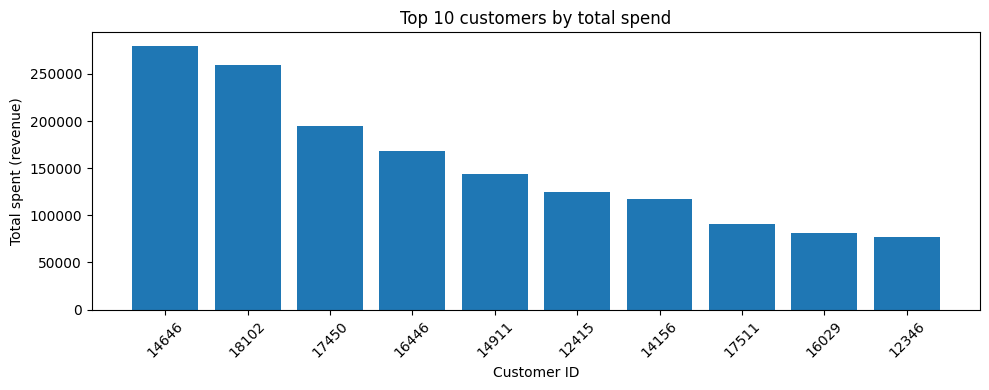

In [67]:
top10 = customer_stats.head(10)

plt.figure(figsize=(10, 4))
plt.bar(top10.index.astype(str), top10["total_spent"])
plt.title("Top 10 customers by total spend")
plt.xlabel("Customer ID")
plt.ylabel("Total spent (revenue)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [68]:
# User-item matrix: rows = customers, columns = products, values = total quantity bought.
# Missing entries become 0 (the customer never bought that product).
user_item = cust.pivot_table(
    index="CustomerID",
    columns="StockCode",
    values="Quantity",
    aggfunc="sum",
    fill_value=0,
)

print("Matrix shape (customers x products):", user_item.shape)
user_item.iloc[:5, :8]  # small corner preview

Matrix shape (customers x products): (4338, 3665)


StockCode,10002,10080,10120,10125,10133,10135,11001,15030
CustomerID,,,,,,,,
12346,0,0,0,0,0,0,0,0
12347,0,0,0,0,0,0,0,0
12348,0,0,0,0,0,0,0,0
12349,0,0,0,0,0,0,0,0
12350,0,0,0,0,0,0,0,0


In [69]:
from sklearn.metrics.pairwise import cosine_similarity

similarity = cosine_similarity(user_item)
similarity_df = pd.DataFrame(
    similarity,
    index=user_item.index,
    columns=user_item.index,
)
print("Similarity matrix shape:", similarity_df.shape)

Similarity matrix shape: (4338, 4338)


In [70]:
product_names = (
    cust.dropna(subset=["Description"])
    .drop_duplicates("StockCode")
    .set_index("StockCode")["Description"]
)

popular_products = user_item.sum().sort_values(ascending=False)  # cold-start fallback


def recommend(customer_id, n_similar=10, n_recommend=5):
    # Cold start: unknown customer (no purchase history) -> recommend the most popular products
    if customer_id not in user_item.index:
        top = popular_products.head(n_recommend)
        return pd.DataFrame(
            {
                "StockCode": top.index,
                "Description": [product_names.get(c, "?") for c in top.index],
                "Score": top.values,
            }
        )

    # Known customer: similarity-weighted collaborative filtering
    similar = (
        similarity_df[customer_id]
        .drop(customer_id)
        .sort_values(ascending=False)
        .head(n_similar)
    )
    weighted = user_item.loc[similar.index].mul(similar.values, axis=0).sum()
    already_bought = user_item.loc[customer_id]
    candidates = weighted[already_bought == 0]
    top = candidates.sort_values(ascending=False).head(n_recommend)
    return pd.DataFrame(
        {
            "StockCode": top.index,
            "Description": [product_names.get(c, "?") for c in top.index],
            "Score": top.values,
        }
    )

In [71]:
recommend(12347)

,StockCode,Description,Score
0,23077,DOUGHNUT LIP GLOSS,77.842993
1,22418,10 COLOUR SPACEBOY PEN,38.156784
2,22693,GROW A FLYTRAP OR SUNFLOWER IN TIN,37.587908
3,22614,PACK OF 12 SPACEBOY TISSUES,33.224178
4,20725,LUNCH BAG RED RETROSPOT,28.986408


In [72]:
recommend(99999)

,StockCode,Description,Score
0,23843,"PAPER CRAFT , LITTLE BIRDIE",80995
1,23166,MEDIUM CERAMIC TOP STORAGE JAR,77916
2,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,54415
3,22197,SMALL POPCORN HOLDER,49183
4,85099B,JUMBO BAG RED RETROSPOT,46181


In [73]:
# Evaluate the recommender with a leave-one-out hit-rate, against a popularity baseline.
# For each sampled customer we hide one product they actually bought, build top-k
# recommendations, and check whether the hidden product shows up among them (a "hit").
def evaluate_recommender(sample_size=300, k=5, seed=42):
    rng = np.random.default_rng(seed)

    # Only customers with enough history to hide one product and still have signal
    counts = (user_item > 0).sum(axis=1)
    eligible = counts[counts >= 5].index.to_numpy()
    sample = rng.choice(eligible, size=min(sample_size, len(eligible)), replace=False)

    popularity = user_item.sum().sort_values(
        ascending=False
    )  # global product popularity

    cf_hits = 0
    pop_hits = 0
    for cid in sample:
        cid = int(cid)
        bought = user_item.loc[cid]
        bought_products = list(bought[bought > 0].index)
        hidden = rng.choice(
            bought_products
        )  # pretend the customer never bought this one

        # Products allowed in the recommendation: not bought, plus the hidden one
        allowed = (bought == 0) | (bought.index == hidden)

        # 1) Collaborative filtering (similarity-weighted) — same logic as recommend()
        similar = similarity_df[cid].drop(cid).sort_values(ascending=False).head(10)
        weighted = user_item.loc[similar.index].mul(similar.values, axis=0).sum()
        cf_topk = weighted[allowed].sort_values(ascending=False).head(k).index
        if hidden in cf_topk:
            cf_hits += 1

        # 2) Popularity baseline: just recommend the most popular products
        pop_topk = popularity[allowed].head(k).index
        if hidden in pop_topk:
            pop_hits += 1

    n = len(sample)
    print(f"Customers evaluated: {n}")
    print(f"Collaborative filtering  hit-rate@{k}: {cf_hits / n:.1%}")
    print(f"Popularity baseline      hit-rate@{k}: {pop_hits / n:.1%}")


evaluate_recommender()

Customers evaluated: 300
Collaborative filtering  hit-rate@5: 4.3%
Popularity baseline      hit-rate@5: 0.7%


## Secinājumi

### Pārdošanas prognoze
Modeļi prognozēja nākamās dienas ieņēmumus, balstoties uz iepriekšējām
7 dienām (lag mainīgie). Datu sadalījums treniņa un testa daļās bija hronoloģisks
(bez sajaukšanas), lai novērstu informācijas noplūdi.

| Modelis | RMSE |
|---|---|
| Random Forest | 26 866 |
| XGBoost | 27 764 |
| LSTM | 30 086 |
| Bāzes līnija | 30 373 |

Vislabāk sevi parādīja Random Forest.

Lai novērtētu, vai modeļi vispār ir noderīgi, tie tika salīdzināti ar bāzes līniju —
vienkāršu pieņēmumu, ka rītdienas ieņēmumi būs tādi paši kā šodien. Random Forest un
XGBoost to pārspēj par ~12% un ~9%, savukārt LSTM bāzes līniju pārspēj minimāli.

Dziļā mācīšanās nepārspēja klasiskos modeļus. Ar tikai ~238 treniņa dienām neironu
tīklam datu bija kritiski maz. Random Forest un XGBoost, kuru pamatā ir lēmumu koki,
ar tik nelielu datu apjomu strādā labāk. Ar nelielām tabulārām datu kopām vienkāršāki
modeļi nereti ir labāka izvēle — lielāka sarežģītība negarantē labāku rezultātu.

Šiem modeļiem ir kopīgs ierobežojums: tie nespēj prognozēt vērtības, kas lielākas par
treniņā redzētajām, tāpēc pirmssvētku ieņēmumu kāpumu tie paredz par zemu.

### Klientu uzvedība
Klientu rādītāji (pasūtījumu skaits, vienību skaits, kopējais tēriņš) parādīja, ka nav
viena konkrēta klientu tipa, uz kuru koncentrēties. Daži pērk bieži un mazos apjomos,
citi reti, bet ļoti lielos apjomos. Abām grupām nepieciešama atšķirīga pieeja.

### Rekomendācijas
Uz klientu līdzību balstīts rekomendētājs (collaborative filtering) iesaka produktus, ko pirkuši līdzīgi klienti un ko mērķa klients vēl nav iegādājies. Praksē tas palīdz piedāvāt papildu
produktus un personalizēt mārketingu, kas var palielināt vidējo pasūtījuma apjomu.

Lai pārbaudītu, vai ieteikumi ir noderīgi, sistēma tika novērtēta ar hit-rate@5: katram
klientam tika paslēpta viena nopirktā produkta pozīcija un pārbaudīts, vai sistēma to ieteiktu starp
šiem pieciem ieteikumiem. Rekomendētājs sasniedza 4,3% — aptuveni sešas reizes vairāk nekā populārāko produktu ieteikšana (0,7%).

### Galvenie ierobežojumi
- Prognoze balstās uz apmēram viena gada datiem, un lag mainīgie izmanto tirdzniecības
  dienu secību, nevis stingru kalendāra secību.
- Jauniem klientiem bez pirkumu vēstures sistēma atkāpjas uz populārākajiem produktiem;
  tas atrisina aukstā starta problēmu, bet šādi ieteikumi nav personalizēti.